In [73]:
import numpy as np
import matplotlib.pyplot as plt

from phase_shift import PhaseSolver, PhaseConfig
from phase_shift.carrier import remove_carrier

def correct(frame, mask):
    ys, xs = np.where(mask)
    corr = frame.astype(float).copy()
    for y, x in zip(ys, xs):
        nb  = frame[max(0,y-1):y+2, max(0,x-1):x+2]
        nbm = mask [max(0,y-1):y+2, max(0,x-1):x+2]
        good = nb[~nbm]
        if good.size: corr[y,x] = np.median(good)
    return corr

N = 20

In [121]:
def get_dark_ref(stack_dark):
    # Find and correct for hot pixels
    frames = stack_dark           # (N,H,W), same gain+exposure as your data

    m = frames.mean(0)                 # per-pixel mean  -> high dark current
    s = frames.std(0)                  # per-pixel std   -> RTS/flicker

    def rob(x, k=5):                   # robust threshold, unbiased by outliers
        med = np.median(x)
        mad = np.median(np.abs(x-med))*1.4826
        return np.abs(x-med) >= k*mad

    mask = rob(m) | rob(s)             # (H,W) bool, True = hot
    print(100*mask.mean(), "% hot")

    stack_dark_corr = np.stack([correct(stack_dark[n], mask) for n in range(len(stack_dark))])
    return stack_dark_corr.mean(axis=0), mask

def get_bright_corr(stack_bright, mask, stack_dark_ref):
    stack_bright_corr = np.stack([correct(stack_bright[n], mask) for n in range(len(stack_bright))])
    return np.maximum(stack_bright_corr - stack_dark_ref, 0)

def get_noise(stack_bright):
    # Compute noise
    sigma_ref_n = np.sqrt(stack_bright*2.6596) / 2.6596    # (N,P), gain=100
    sigma_ref_pixel = np.sqrt((sigma_ref_n**2).mean(0))          # (P,)

    rms_bright = np.sqrt((sigma_ref_pixel**2).mean())
    noise_floor_bright = np.sqrt((sigma_ref_pixel**2).mean()) / stack_bright.std()

    print(f"RMS noise: {rms_bright}")
    print(f"Noise floor: {noise_floor_bright}")
    
    return rms_bright, noise_floor_bright
    
    

def get_phase(stack_dark, stack_bright):
    stack_dark_ref, mask = get_dark_ref(stack_dark)
    stack_bright_corr = get_bright_corr(stack_bright, mask, stack_dark_ref)
    
    rms_bright, noise_floor_bright = get_noise(stack_bright_corr)
    
    iters = 30
    tol = 1e-4
    basis_kwargs = {"degree": 2}
    rounds = 1

    cfg_d = PhaseConfig.from_yaml("phase_config.yaml")
    cfg_d.use_alpha = True
    cfg_d.gain_mode = "joint"
    cfg_d.method_kwargs.update(iters=iters, tol=tol, basis_kwargs=basis_kwargs, rounds=rounds)

    solver_d = PhaseSolver(cfg_d)
    solver_d.fit(stack_bright_corr)
    
    r = solver_d.result
    
    carrier_res = remove_carrier(r.phi, r.b, degree=2, window=5, subsample=4)
    
    return carrier_res.phi
    
    

In [35]:
# Read dark frames
data_dark = np.load("../../data/dark_400_20260907_134803.npz")
stack_dark = data_dark['stack'][0]

In [86]:
# Read ref bright frames
data_ref_bright = np.load("../../data/piezo_ref_bright_400_20260907_134514.npz")
stack_ref_bright = data_ref_bright['stack'][0][:N]

In [87]:
# Read sample bright frames
data_sample_bright = np.load("../../data/piezo_sample_bright_400_20260907_135149.npz")
stack_sample_bright = data_sample_bright['stack'][0][:N]

In [122]:
phi_ref = get_phase(stack_dark, stack_ref_bright)
phi_sample = get_phase(stack_dark, stack_sample_bright)

0.0750137741046832 % hot
RMS noise: 12.976838827607322
Noise floor: 0.056726163422899725
0.0750137741046832 % hot
RMS noise: 11.875078831085956
Noise floor: 0.061194304980116215


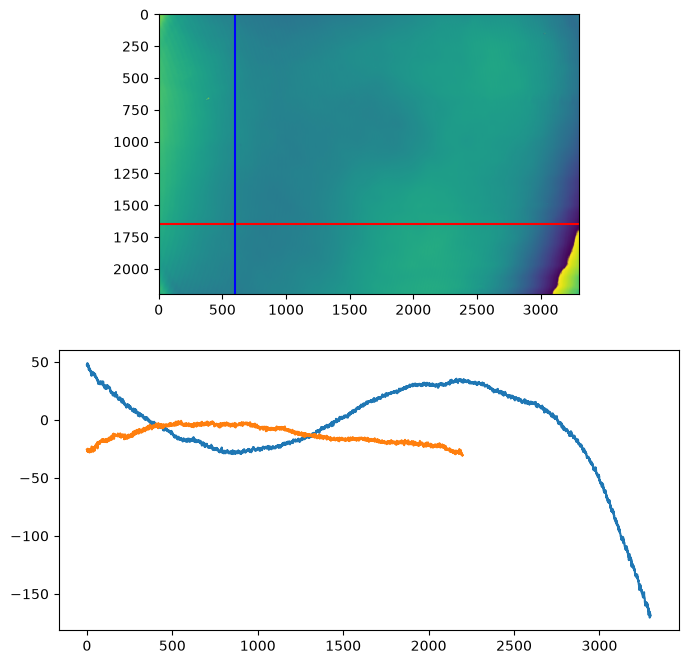

In [128]:
phi_diff = phi_sample - phi_ref

phi_check = phi_ref

y = 1650
x = 600

plt.figure(figsize=(8, 8))
plt.subplot(211)
plt.imshow(phi_check)
plt.hlines(y, xmin=0, xmax=phi_check.shape[-1], color="r")
plt.vlines(x, ymin=0, ymax=phi_check.shape[-2], color="b")
plt.xlim([0, phi_check.shape[-1]])
plt.ylim([phi_check.shape[-2], 0])


plt.subplot(212)
plt.plot(phi_check[y]*180/np.pi)
plt.plot(phi_check[:,x]*180/np.pi)

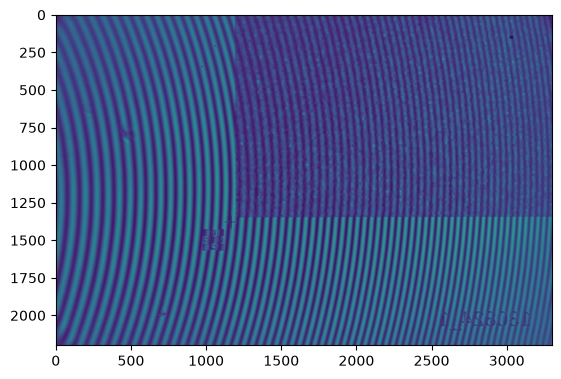

In [127]:
plt.imshow(stack_sample_bright[0])

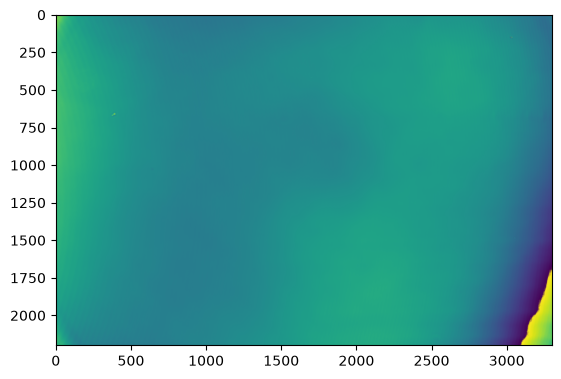

In [126]:
plt.imshow(phi_ref)